# 03 — The metric zoo

Phase 1 deliverable. Loads Pythia-160M @ `step143000`, runs every metric in `hybrid_arch` on a fixed WikiText-103 slice, builds a per-token table, computes the correlation matrix between metrics, saves it to `docs/results/01_metric_correlations.csv`, and renders example plots.

**Compute budget:** designed to run end-to-end on a free Colab CPU runtime in roughly 3-5 minutes. The bottleneck is `parallel_prediction_agreement`, which does O(n_tokens × k) forward passes. To stay in budget on CPU, the default slice is 256 tokens. Bump `N_TOKENS` if you have GPU.

**What the correlation matrix shows.** With five complementary metrics, we want to know which ones overlap (and so are redundant) and which carry independent signal. Phase 2's analysis will lean on the ones that don't already correlate with each other near 1.

In [1]:
# --- Imports & seeds --------------------------------------------------------
import hashlib
import json
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from hybrid_arch import (
    attention_concentration,
    attention_entropy,
    attention_track,
    entropy_heatmap,
    extract_attention,
    next_token_entropy,
    parallel_prediction_agreement,
    top1_probability,
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

print('torch', torch.__version__)
import transformers; print('transformers', transformers.__version__)
import datasets; print('datasets', datasets.__version__)

torch 2.12.0


transformers 5.9.0


datasets 4.8.5


In [2]:
# --- Configuration ----------------------------------------------------------
MODEL_NAME = 'EleutherAI/pythia-160m'
MODEL_REV  = 'step143000'

N_TOKENS   = 256   # slice length; 256 is the CPU-friendly default
K_PARALLEL = 4     # lookahead for parallel_prediction_agreement

# Paths are relative to this notebook's directory (notebooks/).
ROOT      = Path('..').resolve()
DATA_DIR  = ROOT / 'data'
RESULTS   = ROOT / 'docs' / 'results'
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

SLICE_CACHE = DATA_DIR / f'wikitext_slice_{N_TOKENS}.pt'
CSV_OUT     = RESULTS / '01_metric_correlations.csv'
MANIFEST    = RESULTS / '01_metric_correlations.manifest.json'

print('Config:', dict(model=MODEL_NAME, rev=MODEL_REV, n=N_TOKENS, k=K_PARALLEL))

Config: {'model': 'EleutherAI/pythia-160m', 'rev': 'step143000', 'n': 256, 'k': 4}


## 1. Load the model

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer

t0 = time.perf_counter()
tok   = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REV)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, revision=MODEL_REV, torch_dtype=torch.float32)
model.eval()
print(f'Loaded {MODEL_NAME} @ {MODEL_REV} in {time.perf_counter()-t0:.1f}s')
print('  hidden_size =', model.config.hidden_size)
print('  n_layers    =', model.config.num_hidden_layers)
print('  n_heads     =', model.config.num_attention_heads)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded EleutherAI/pythia-160m @ step143000 in 0.9s
  hidden_size = 768
  n_layers    = 12
  n_heads     = 12


## 2. Load a WikiText-103 slice

Streamed from HuggingFace on first run, cached locally as a tensor afterwards. The cache file is gitignored under `data/`.

In [4]:
if SLICE_CACHE.exists():
    input_ids = torch.load(SLICE_CACHE)
    print(f'Loaded cached slice from {SLICE_CACHE}')
else:
    from datasets import load_dataset
    ds = load_dataset('Salesforce/wikitext', 'wikitext-103-raw-v1', split='train', streaming=True)
    pieces = []
    chars  = 0
    for item in ds:
        if item['text'].strip():
            pieces.append(item['text'])
            chars += len(item['text'])
        # ~4 chars / token is a safe overestimate -> ~6x the chars we need
        if chars > N_TOKENS * 6:
            break
    text = ' '.join(pieces)
    enc = tok(text, return_tensors='pt', truncation=False)
    input_ids = enc.input_ids[:, :N_TOKENS].contiguous()
    torch.save(input_ids, SLICE_CACHE)
    print(f'Cached {N_TOKENS}-token slice to {SLICE_CACHE}')

assert input_ids.shape == (1, N_TOKENS), input_ids.shape
print('First 80 chars:', repr(tok.decode(input_ids[0, :30])))

Cached 256-token slice to /Users/mohamedmagzoub/Documents/Claude/Projects/Hybrid Architecture/data/wikitext_slice_256.pt
First 80 chars: ' = Valkyria Chronicles III = \n  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : �'


## 3. Run a forward pass to capture logits and attention

Logits feed the logit-side metrics; the forward-hook extractor in `hybrid_arch.attention` gives us NaN-free attention for every layer.

In [5]:
t0 = time.perf_counter()
with torch.no_grad():
    logits = model(input_ids=input_ids).logits  # [1, N_TOKENS, vocab]
attn = extract_attention(model, input_ids)        # [L, 1, H, N, N]
print(f'Forward + attention extract: {time.perf_counter()-t0:.1f}s')
print('logits shape:', tuple(logits.shape))
print('attn   shape:', tuple(attn.shape))
assert not torch.isnan(attn).any(), 'attention contains NaN'

Forward + attention extract: 1.0s
logits shape: (1, 256, 50304)
attn   shape: (12, 1, 12, 256, 256)


## 4. Logit-side metrics

In [6]:
tok_entropy = next_token_entropy(logits)[0]   # [N_TOKENS]
tok_top1    = top1_probability(logits)[0]     # [N_TOKENS]
print('next_token_entropy:', tok_entropy.shape, tok_entropy.mean().item())
print('top1_probability  :', tok_top1.shape,    tok_top1.mean().item())

next_token_entropy: torch.Size([256]) 3.944979667663574
top1_probability  : torch.Size([256]) 0.34056633710861206


## 5. Attention-side metrics

`attention_entropy` and `attention_concentration` return one value per (layer, head, query position). For the correlation matrix we want one value per token, so we average across layers and heads. Phase 2 will examine the layer/head structure properly.

In [7]:
attn_h = attention_entropy(attn)                                # [L, 1, H, N]
attn_c = attention_concentration(attn, top_k=(1, 3, 5))         # [3, L, 1, H, N]

# Aggregate across L and H (and the singleton batch dim).
attn_entropy_per_tok = attn_h.mean(dim=(0, 1, 2))               # [N]
attn_top1_per_tok    = attn_c[0].mean(dim=(0, 1, 2))            # [N]
attn_top3_per_tok    = attn_c[1].mean(dim=(0, 1, 2))            # [N]
attn_top5_per_tok    = attn_c[2].mean(dim=(0, 1, 2))            # [N]

print('attn_entropy_per_tok:', attn_entropy_per_tok.shape, attn_entropy_per_tok.mean().item())
print('attn_top1_per_tok   :', attn_top1_per_tok.shape,    attn_top1_per_tok.mean().item())

attn_entropy_per_tok: torch.Size([256]) 1.4473915100097656
attn_top1_per_tok   : torch.Size([256]) 0.6006273031234741


## 6. Parallel-prediction agreement

The headline metric. Aggregating across the `k` lookahead steps gives one agreement rate per position. Roughly O(N × K) forward passes — this is the slow cell.

In [8]:
t0 = time.perf_counter()
agreement = parallel_prediction_agreement(model, input_ids, k=K_PARALLEL)  # [1, N-K, K]
agreement_rate = agreement[0].float().mean(dim=-1)                          # [N-K]
print(f'parallel_prediction_agreement: {time.perf_counter()-t0:.1f}s')
print('agreement shape    :', tuple(agreement.shape))
print('avg agreement rate :', agreement_rate.mean().item())
print('avg j=0 (must=1.0) :', agreement[0, :, 0].float().mean().item())

parallel_prediction_agreement: 42.1s
agreement shape    : (1, 252, 4)
avg agreement rate : 0.4275793731212616
avg j=0 (must=1.0) : 1.0


## 7. Assemble per-token table and correlation matrix

All metrics are aligned on positions `0 … N - K - 1` so they share the same n samples. Position 0 has structural zeros for the attention-side metrics under causal masking (only one key visible), so we drop it from the correlation analysis to avoid artefactually pulling correlations toward the structural relationship.

In [9]:
N_VALID = N_TOKENS - K_PARALLEL  # parallel-agreement defines the upper bound
metric_names = [
    'next_token_entropy',
    'top1_probability',
    'attention_entropy',
    'attention_top1',
    'attention_top3',
    'attention_top5',
    'parallel_agreement',
]

# Stack into [N_VALID, n_metrics]. Drop position 0 (structural).
cols = [
    tok_entropy[:N_VALID].numpy(),
    tok_top1[:N_VALID].numpy(),
    attn_entropy_per_tok[:N_VALID].numpy(),
    attn_top1_per_tok[:N_VALID].numpy(),
    attn_top3_per_tok[:N_VALID].numpy(),
    attn_top5_per_tok[:N_VALID].numpy(),
    agreement_rate.numpy(),
]
table = np.stack(cols, axis=1)[1:]  # drop position 0
print('table shape:', table.shape, '  metrics:', len(metric_names))

corr = np.corrcoef(table, rowvar=False)
print('correlation matrix:')
for i, name in enumerate(metric_names):
    row = '  '.join(f'{c:+.2f}' for c in corr[i])
    print(f'  {name:>22s}  {row}')

table shape: (251, 7)   metrics: 7
correlation matrix:
      next_token_entropy  +1.00  -0.92  +0.09  -0.16  -0.07  -0.03  -0.43
        top1_probability  -0.92  +1.00  -0.11  +0.16  +0.09  +0.06  +0.49
       attention_entropy  +0.09  -0.11  +1.00  -0.89  -0.99  -0.97  -0.08
          attention_top1  -0.16  +0.16  -0.89  +1.00  +0.86  +0.77  +0.11
          attention_top3  -0.07  +0.09  -0.99  +0.86  +1.00  +0.98  +0.07
          attention_top5  -0.03  +0.06  -0.97  +0.77  +0.98  +1.00  +0.05
      parallel_agreement  -0.43  +0.49  -0.08  +0.11  +0.07  +0.05  +1.00


## 8. Save the CSV

Written to `docs/results/01_metric_correlations.csv`. Small file, committed to the repo (this is the published Phase 1 artefact).

In [10]:
header = ',' + ','.join(metric_names)
rows = [header]
for i, name in enumerate(metric_names):
    rows.append(name + ',' + ','.join(f'{c:.6f}' for c in corr[i]))
CSV_OUT.write_text('\n'.join(rows) + '\n')
print(f'Wrote {CSV_OUT.relative_to(ROOT)}')

Wrote docs/results/01_metric_correlations.csv


## 9. Visualizations

Token strip showing next-token entropy and a line track for attention entropy on the first 30 tokens — small enough that the labels stay readable.

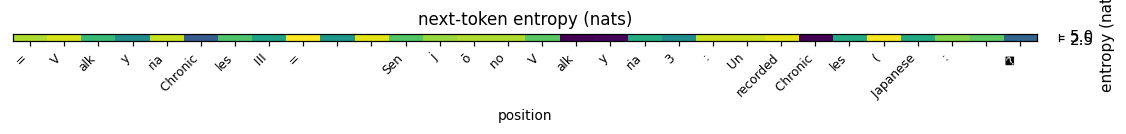

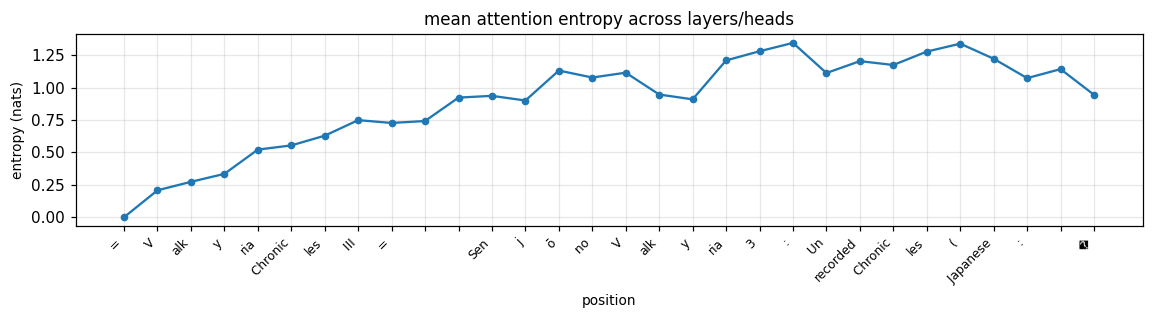

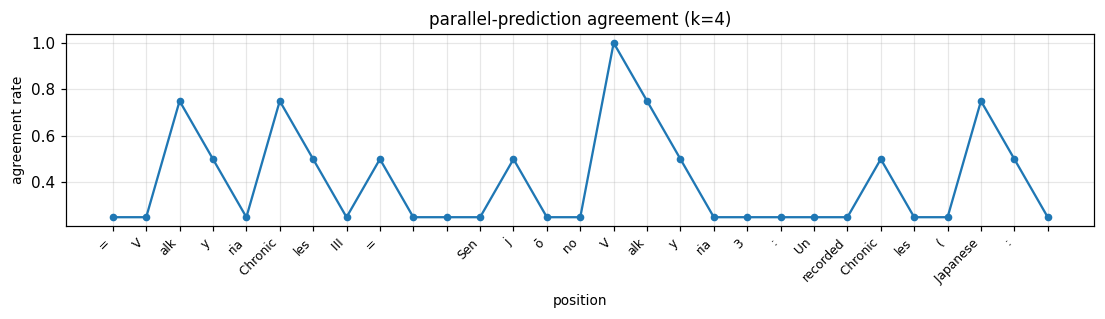

In [11]:
WINDOW = 30
token_strs = [tok.decode([t]) for t in input_ids[0, :WINDOW].tolist()]

fig1 = entropy_heatmap(token_strs, tok_entropy[:WINDOW], title='next-token entropy (nats)')
plt.show()

fig2 = attention_track(
    token_strs,
    attn_entropy_per_tok[:WINDOW],
    title='mean attention entropy across layers/heads',
    ylabel='entropy (nats)',
)
plt.show()

fig3 = attention_track(
    token_strs[:WINDOW-1],  # parallel agreement excludes the last K positions
    agreement_rate[:WINDOW-1],
    title=f'parallel-prediction agreement (k={K_PARALLEL})',
    ylabel='agreement rate',
)
plt.show()

## 10. Manifest

Per CLAUDE.md §9, every published artefact gets a sidecar `manifest.json` so the run is reproducible. Records model + revision hash, dataset slice hash, seed, git commit, wall-clock time.

In [12]:
def _git_commit():
    try:
        out = subprocess.check_output(
            ['git', 'rev-parse', 'HEAD'], cwd=ROOT, stderr=subprocess.DEVNULL
        )
        return out.decode().strip()
    except Exception:
        return None

slice_hash = hashlib.sha256(input_ids.numpy().tobytes()).hexdigest()
manifest = {
    'model_name': MODEL_NAME,
    'model_revision': MODEL_REV,
    'dataset': 'Salesforce/wikitext / wikitext-103-raw-v1 / train (streamed)',
    'n_tokens': N_TOKENS,
    'k_parallel': K_PARALLEL,
    'seed': SEED,
    'slice_sha256': slice_hash,
    'git_commit': _git_commit(),
    'output_csv': str(CSV_OUT.relative_to(ROOT)),
}
MANIFEST.write_text(json.dumps(manifest, indent=2) + '\n')
print(f'Wrote {MANIFEST.relative_to(ROOT)}')
print(json.dumps(manifest, indent=2))

Wrote docs/results/01_metric_correlations.manifest.json
{
  "model_name": "EleutherAI/pythia-160m",
  "model_revision": "step143000",
  "dataset": "Salesforce/wikitext / wikitext-103-raw-v1 / train (streamed)",
  "n_tokens": 256,
  "k_parallel": 4,
  "seed": 0,
  "slice_sha256": "26d082fc2a33069d549cb5712bf8ce328dedc63283009785789d6a13e3a73a9b",
  "git_commit": null,
  "output_csv": "docs/results/01_metric_correlations.csv"
}
